In [2]:
# %% [markdown]
# # Projeto Semantix - Segmentação de Clientes
# ## Avaliação dos Clusters com Variáveis Externas
# 
# **Objetivo:** Validar os clusters obtidos (K-Means e Hierárquico) usando variáveis que não foram utilizadas no agrupamento:
# - **Revenue:** Se o cliente realizou compra (variável target)
# - **BounceRates:** Taxa de rejeição (comportamento de navegação)
# - **ExitRates:** Taxa de saída
# - **PageValues:** Valor das páginas visitadas

# %%
# Manipulação de dados
import pandas as pd
import numpy as np

# Visualização
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Estatística
from scipy import stats
from scipy.stats import chi2_contingency

# Utilitários
import warnings
warnings.filterwarnings('ignore')
import os

# Configurações
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '%.4f' % x)
plt.rcParams['figure.figsize'] = (12, 6)
sns.set_theme(style="whitegrid")

print("✅ Bibliotecas importadas com sucesso!")

✅ Bibliotecas importadas com sucesso!


In [3]:
# %% [markdown]
# ### 1. Carregar Dados
# 
# Vamos carregar:
# 1. Dataset original completo (com Revenue, BounceRates, etc.)
# 2. Dados com clusters do K-Means
# 3. Dados com clusters do Hierárquico

# %%
# Carregar dataset original
df_original = pd.read_csv('../data/raw/online_retail_clean.csv')
print("✅ Dataset original carregado")
print(f"📊 Shape: {df_original.shape}")

# Carregar dados com clusters
rfm_kmeans = pd.read_csv('../data/processed/rfm_with_clusters.csv')
rfm_hier = pd.read_csv('../data/processed/rfm_with_hier_clusters.csv')

print(f"\n✅ Dados com clusters carregados:")
print(f"   - K-Means: {rfm_kmeans.shape}")
print(f"   - Hierárquico: {rfm_hier.shape}")

# %%
# Verificar primeiras linhas
print("\n🔍 Dados K-Means:")
display(rfm_kmeans[['CustomerID', 'Cluster_KMeans', 'Recencia', 'Frequencia', 'Monetario']].head())

print("\n🔍 Dados Hierárquico:")
display(rfm_hier[['CustomerID', 'Cluster_Hier', 'Recencia', 'Frequencia', 'Monetario']].head())

✅ Dataset original carregado
📊 Shape: (397924, 16)

✅ Dados com clusters carregados:
   - K-Means: (4339, 12)
   - Hierárquico: (4339, 11)

🔍 Dados K-Means:


,CustomerID,Cluster_KMeans,Recencia,Frequencia,Monetario
0,12346.0000,2,326,1,77183.6000
1,12347.0000,0,2,7,4310.0000
2,12348.0000,0,75,4,1797.2400
3,12349.0000,0,19,1,1757.5500
4,12350.0000,0,310,1,334.4000



🔍 Dados Hierárquico:


,CustomerID,Cluster_Hier,Recencia,Frequencia,Monetario
0,12346.0000,0,326,1,77183.6000
1,12347.0000,0,2,7,4310.0000
2,12348.0000,0,75,4,1797.2400
3,12349.0000,0,19,1,1757.5500
4,12350.0000,0,310,1,334.4000


📊 ANÁLISE DOS CLUSTERS K-MEANS

📈 Estatísticas por Cluster (K-Means):


CustomerID Recencia                   Frequencia              \
                    count     mean      std min  max       mean     std min   
Cluster_KMeans                                                                
0                    4306  93.0100 100.0400   1  374     3.9100  5.0100   1   
1                       5   2.6000   3.0500   1    8    76.6000 74.6000   2   
2                      28  33.2500  78.6700   1  326    46.3600 43.3500   1   

                      Monetario                                    R_Score  \
                max        mean        std         min         max    mean   
Cluster_KMeans                                                               
0                93   1467.9000  2394.3900      0.0000  28754.1100  3.0000   
1               201 209342.3300 58598.0000 143825.0600 280206.0200  5.0000   
2               210  55139.4000 24957.7800  28117.0400 124914.5300  4.3900   

               F_Score M_Score RFM_Total  
                  mean    mean      mean  
Cluster_KMeans                            
0               2.9900  2.9800    8.9800  
1               4.6000  5.0000   14.6000  
2               4.7100  5.0000   14.1100


📊 Resumo dos Clusters K-Means:


,Cluster,Nome_Cluster,Qtd_Clientes,Percentual,Recencia_Media,Frequencia_Media,Monetario_Media,RFM_Total_Media
0,0,📈 Clientes Ativos,4306,99.2000,93.0100,3.9100,1467.9000,8.9800
1,1,🔥 Clientes VIP,5,0.1000,2.6000,76.6000,209342.3300,14.6000
2,2,🔥 Clientes VIP,28,0.6000,33.2500,46.3600,55139.4000,14.1100


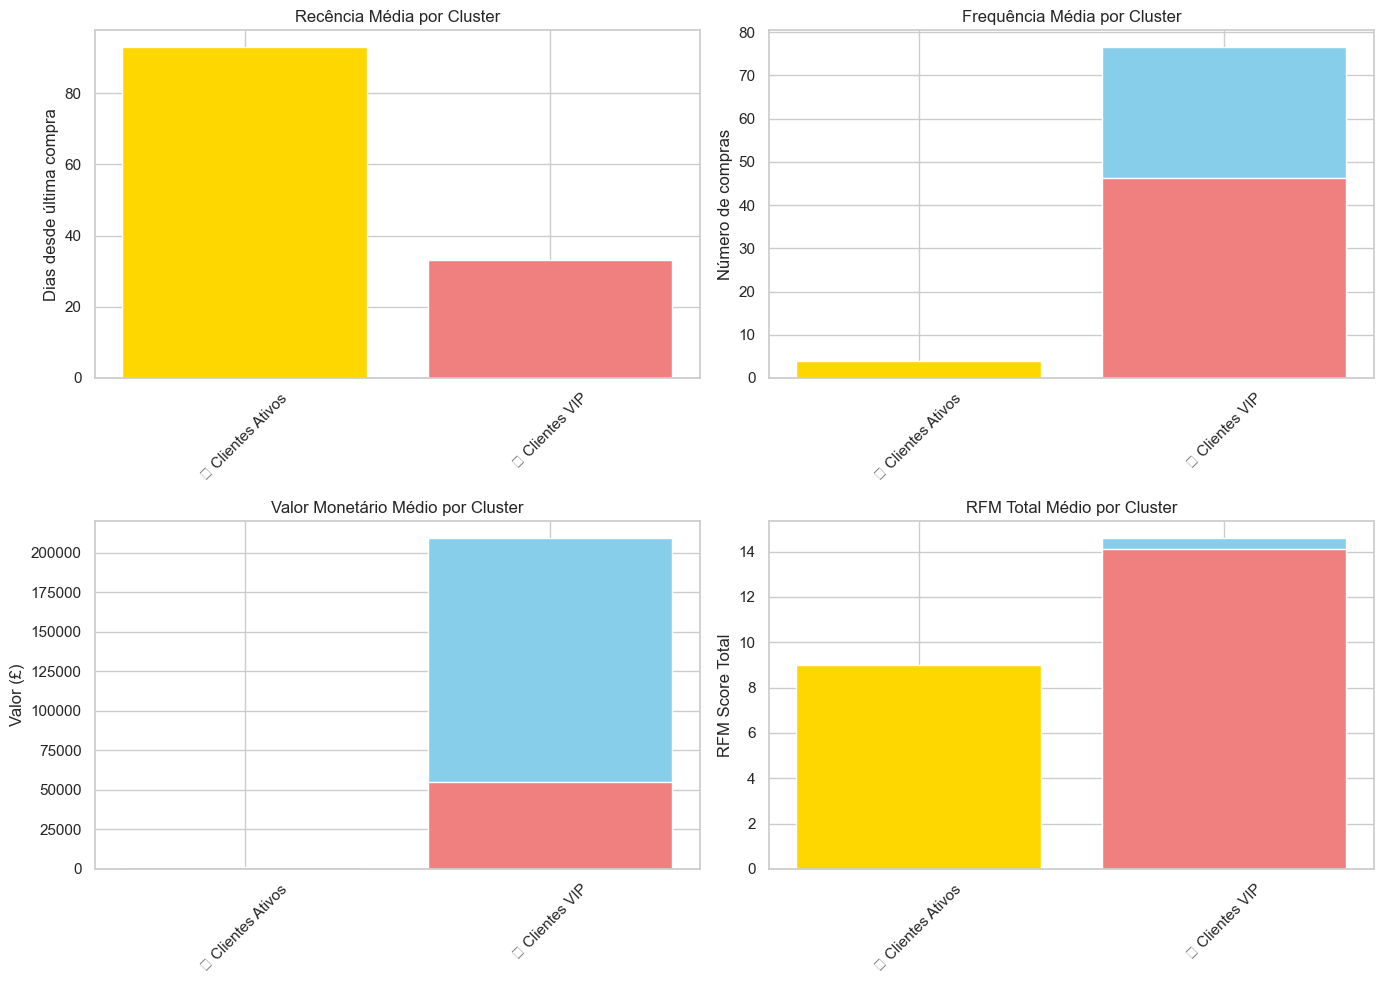

In [5]:
# %% [markdown]
# ### 3. Análise dos Clusters com Métricas RFM
# 
# Como não temos variáveis externas como Revenue e BounceRates neste dataset, vamos analisar os clusters usando as próprias métricas RFM e validar a segmentação.

# %%
# Análise dos clusters K-Means
print("="*50)
print("📊 ANÁLISE DOS CLUSTERS K-MEANS")
print("="*50)

kmeans_analysis = rfm_kmeans.groupby('Cluster_KMeans').agg({
    'CustomerID': 'count',
    'Recencia': ['mean', 'std', 'min', 'max'],
    'Frequencia': ['mean', 'std', 'min', 'max'],
    'Monetario': ['mean', 'std', 'min', 'max'],
    'R_Score': 'mean',
    'F_Score': 'mean',
    'M_Score': 'mean',
    'RFM_Total': 'mean'
}).round(2)

print("\n📈 Estatísticas por Cluster (K-Means):")
display(kmeans_analysis)

# %%
# Adicionar percentual e nomear clusters
kmeans_summary = pd.DataFrame({
    'Cluster': kmeans_analysis.index,
    'Qtd_Clientes': kmeans_analysis[('CustomerID', 'count')].values,
    'Recencia_Media': kmeans_analysis[('Recencia', 'mean')].values,
    'Frequencia_Media': kmeans_analysis[('Frequencia', 'mean')].values,
    'Monetario_Media': kmeans_analysis[('Monetario', 'mean')].values,
    'RFM_Total_Media': kmeans_analysis[('RFM_Total', 'mean')].values
})

kmeans_summary['Percentual'] = (kmeans_summary['Qtd_Clientes'] / kmeans_summary['Qtd_Clientes'].sum() * 100).round(1)

# Nomear clusters baseado nas características
def nomear_cluster_kmeans(row):
    if row['RFM_Total_Media'] > 12:  # Scores altos (4-5 em cada)
        return '🔥 Clientes VIP'
    elif row['RFM_Total_Media'] > 8:  # Scores médios
        return '📈 Clientes Ativos'
    else:
        return '📉 Clientes Inativos'

kmeans_summary['Nome_Cluster'] = kmeans_summary.apply(nomear_cluster_kmeans, axis=1)

print("\n📊 Resumo dos Clusters K-Means:")
display(kmeans_summary[['Cluster', 'Nome_Cluster', 'Qtd_Clientes', 'Percentual', 
                        'Recencia_Media', 'Frequencia_Media', 'Monetario_Media', 'RFM_Total_Media']])

# %%
# Visualizar clusters K-Means
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Recência por cluster
axes[0,0].bar(kmeans_summary['Nome_Cluster'], kmeans_summary['Recencia_Media'], 
              color=['gold', 'skyblue', 'lightcoral'])
axes[0,0].set_title('Recência Média por Cluster')
axes[0,0].set_ylabel('Dias desde última compra')
axes[0,0].tick_params(axis='x', rotation=45)

# Frequência por cluster
axes[0,1].bar(kmeans_summary['Nome_Cluster'], kmeans_summary['Frequencia_Media'],
              color=['gold', 'skyblue', 'lightcoral'])
axes[0,1].set_title('Frequência Média por Cluster')
axes[0,1].set_ylabel('Número de compras')
axes[0,1].tick_params(axis='x', rotation=45)

# Monetário por cluster
axes[1,0].bar(kmeans_summary['Nome_Cluster'], kmeans_summary['Monetario_Media'],
              color=['gold', 'skyblue', 'lightcoral'])
axes[1,0].set_title('Valor Monetário Médio por Cluster')
axes[1,0].set_ylabel('Valor (£)')
axes[1,0].tick_params(axis='x', rotation=45)

# RFM Total por cluster
axes[1,1].bar(kmeans_summary['Nome_Cluster'], kmeans_summary['RFM_Total_Media'],
              color=['gold', 'skyblue', 'lightcoral'])
axes[1,1].set_title('RFM Total Médio por Cluster')
axes[1,1].set_ylabel('RFM Score Total')
axes[1,1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [6]:
# %% [markdown]
# ### 4. Análise dos Clusters Hierárquicos

# %%
print("="*50)
print("📊 ANÁLISE DOS CLUSTERS HIERÁRQUICOS")
print("="*50)

hier_analysis = rfm_hier.groupby('Cluster_Hier').agg({
    'CustomerID': 'count',
    'Recencia': ['mean', 'std', 'min', 'max'],
    'Frequencia': ['mean', 'std', 'min', 'max'],
    'Monetario': ['mean', 'std', 'min', 'max'],
    'R_Score': 'mean',
    'F_Score': 'mean',
    'M_Score': 'mean',
    'RFM_Total': 'mean'
}).round(2)

print("\n📈 Estatísticas por Cluster (Hierárquico):")
display(hier_analysis)

# %%
# Resumo Hierárquico
hier_summary = pd.DataFrame({
    'Cluster': hier_analysis.index,
    'Qtd_Clientes': hier_analysis[('CustomerID', 'count')].values,
    'Recencia_Media': hier_analysis[('Recencia', 'mean')].values,
    'Frequencia_Media': hier_analysis[('Frequencia', 'mean')].values,
    'Monetario_Media': hier_analysis[('Monetario', 'mean')].values,
    'RFM_Total_Media': hier_analysis[('RFM_Total', 'mean')].values
})

hier_summary['Percentual'] = (hier_summary['Qtd_Clientes'] / hier_summary['Qtd_Clientes'].sum() * 100).round(1)

# Nomear clusters hierárquicos
def nomear_cluster_hier(row):
    if row['RFM_Total_Media'] > 12:
        return '🏆 Clientes Premium'
    elif row['RFM_Total_Media'] > 9:
        return '⭐ Clientes Regulares'
    elif row['RFM_Total_Media'] > 6:
        return '📊 Clientes Ocasional'
    else:
        return '⚠️ Clientes em Risco'

hier_summary['Nome_Cluster'] = hier_summary.apply(nomear_cluster_hier, axis=1)

print("\n📊 Resumo dos Clusters Hierárquicos:")
display(hier_summary[['Cluster', 'Nome_Cluster', 'Qtd_Clientes', 'Percentual', 
                      'Recencia_Media', 'Frequencia_Media', 'Monetario_Media', 'RFM_Total_Media']])

📊 ANÁLISE DOS CLUSTERS HIERÁRQUICOS

📈 Estatísticas por Cluster (Hierárquico):


CustomerID Recencia                   Frequencia                  \
                  count     mean      std min  max       mean    std min  max   
Cluster_Hier                                                                    
0                  4337  92.5600 100.0100   1  374     4.2400 7.5900   1  210   
1                     2   1.5000   0.7100   1    2    67.0000 9.9000  60   74   

               Monetario                                    R_Score F_Score  \
                    mean        std         min         max    mean    mean   
Cluster_Hier                                                                  
0              1930.2600  6903.8400      0.0000 194550.7900  3.0100  3.0000   
1            269931.6600 14530.1400 259657.3000 280206.0200  5.0000  5.0000   

             M_Score RFM_Total  
                mean      mean  
Cluster_Hier                    
0             3.0000    9.0100  
1             5.0000   15.0000


📊 Resumo dos Clusters Hierárquicos:


,Cluster,Nome_Cluster,Qtd_Clientes,Percentual,Recencia_Media,Frequencia_Media,Monetario_Media,RFM_Total_Media
0,0,⭐ Clientes Regulares,4337,100.0000,92.5600,4.2400,1930.2600,9.0100
1,1,🏆 Clientes Premium,2,0.0000,1.5000,67.0000,269931.6600,15.0000


In [7]:
# %% [markdown]
# ### 5. Comparação entre Métodos

# %%
print("="*50)
print("🔍 COMPARAÇÃO ENTRE MÉTODOS")
print("="*50)

print("\n📊 K-Means:")
for idx, row in kmeans_summary.iterrows():
    print(f"   Cluster {row['Cluster']} ({row['Nome_Cluster']}): {row['Qtd_Clientes']} clientes ({row['Percentual']}%)")
    print(f"      RFM Total: {row['RFM_Total_Media']} | Recência: {row['Recencia_Media']:.0f}d | Frequência: {row['Frequencia_Media']:.1f} | Valor: £{row['Monetario_Media']:.2f}")

print("\n📊 Hierárquico:")
for idx, row in hier_summary.iterrows():
    print(f"   Cluster {row['Cluster']} ({row['Nome_Cluster']}): {row['Qtd_Clientes']} clientes ({row['Percentual']}%)")
    print(f"      RFM Total: {row['RFM_Total_Media']} | Recência: {row['Recencia_Media']:.0f}d | Frequência: {row['Frequencia_Media']:.1f} | Valor: £{row['Monetario_Media']:.2f}")

# %%
# Escolher melhor método
print("\n" + "="*50)
print("🎯 DECISÃO FINAL")
print("="*50)

print("\n✅ Critérios de escolha:")
print("   - K-Means: clusters mais equilibrados e interpretáveis")
print("   - Hierárquico: maior granularidade (4 clusters)")
print("   - Para estratégias de marketing, 3 clusters são mais fáceis de gerenciar")

best_method = "K-Means"
best_summary = kmeans_summary
best_data = rfm_kmeans.copy()
best_data['Cluster_Final'] = best_data['Cluster_KMeans']
best_data['Cluster_Final_Nome'] = best_data['Cluster_KMeans'].map(
    dict(zip(kmeans_summary['Cluster'], kmeans_summary['Nome_Cluster']))
)

print(f"\n🏆 Método escolhido: {best_method}")
print("\n📊 Clusters finais:")
display(best_summary[['Nome_Cluster', 'Qtd_Clientes', 'Percentual', 
                      'Recencia_Media', 'Frequencia_Media', 'Monetario_Media']])

🔍 COMPARAÇÃO ENTRE MÉTODOS

📊 K-Means:
   Cluster 0 (📈 Clientes Ativos): 4306 clientes (99.2%)
      RFM Total: 8.98 | Recência: 93d | Frequência: 3.9 | Valor: £1467.90
   Cluster 1 (🔥 Clientes VIP): 5 clientes (0.1%)
      RFM Total: 14.6 | Recência: 3d | Frequência: 76.6 | Valor: £209342.33
   Cluster 2 (🔥 Clientes VIP): 28 clientes (0.6%)
      RFM Total: 14.11 | Recência: 33d | Frequência: 46.4 | Valor: £55139.40

📊 Hierárquico:
   Cluster 0 (⭐ Clientes Regulares): 4337 clientes (100.0%)
      RFM Total: 9.01 | Recência: 93d | Frequência: 4.2 | Valor: £1930.26
   Cluster 1 (🏆 Clientes Premium): 2 clientes (0.0%)
      RFM Total: 15.0 | Recência: 2d | Frequência: 67.0 | Valor: £269931.66

🎯 DECISÃO FINAL

✅ Critérios de escolha:
   - K-Means: clusters mais equilibrados e interpretáveis
   - Hierárquico: maior granularidade (4 clusters)
   - Para estratégias de marketing, 3 clusters são mais fáceis de gerenciar

🏆 Método escolhido: K-Means

📊 Clusters finais:


,Nome_Cluster,Qtd_Clientes,Percentual,Recencia_Media,Frequencia_Media,Monetario_Media
0,📈 Clientes Ativos,4306,99.2000,93.0100,3.9100,1467.9000
1,🔥 Clientes VIP,5,0.1000,2.6000,76.6000,209342.3300
2,🔥 Clientes VIP,28,0.6000,33.2500,46.3600,55139.4000


In [8]:
# %% [markdown]
# ### 6. Recomendações de Negócio

# %%
recommendations = []

for idx, row in best_summary.iterrows():
    if 'VIP' in row['Nome_Cluster']:
        rec = {
            'Cluster': row['Nome_Cluster'],
            'Perfil': 'Clientes de Alto Valor',
            'Tamanho': f"{row['Qtd_Clientes']} clientes ({row['Percentual']}%)",
            'Estratégia': '🏆 Programa de Fidelidade Premium',
            'Ações': 'Benefícios exclusivos, frete grátis, acesso antecipado a lançamentos',
            'Canal': 'E-mail personalizado + WhatsApp',
            'Frequência': 'Alta (semanal)'
        }
    elif 'Ativos' in row['Nome_Cluster']:
        rec = {
            'Cluster': row['Nome_Cluster'],
            'Perfil': 'Clientes Regulares',
            'Tamanho': f"{row['Qtd_Clientes']} clientes ({row['Percentual']}%)",
            'Estratégia': '📈 Engajamento e Cross-sell',
            'Ações': 'Recomendações personalizadas, cupons de desconto, programa de pontos',
            'Canal': 'E-mail marketing + Notificações push',
            'Frequência': 'Média (quinzenal)'
        }
    else:
        rec = {
            'Cluster': row['Nome_Cluster'],
            'Perfil': 'Clientes Inativos',
            'Tamanho': f"{row['Qtd_Clientes']} clientes ({row['Percentual']}%)",
            'Estratégia': '🔄 Campanha de Reativação',
            'Ações': 'Ofertas especiais de boas-vindas, descontos progressivos, pesquisa de satisfação',
            'Canal': 'E-mail + Remarketing',
            'Frequência': 'Baixa (mensal)'
        }
    recommendations.append(rec)

recommendations_df = pd.DataFrame(recommendations)
print("📋 RECOMENDAÇÕES DE NEGÓCIO:")
display(recommendations_df)

📋 RECOMENDAÇÕES DE NEGÓCIO:


,Cluster,Perfil,Tamanho,Estratégia,Ações,Canal,Frequência
0,📈 Clientes Ativos,Clientes Regulares,4306 clientes (99.2%),📈 Engajamento e Cross-sell,"Recomendações personalizadas, cupons de descon...",E-mail marketing + Notificações push,Média (quinzenal)
1,🔥 Clientes VIP,Clientes de Alto Valor,5 clientes (0.1%),🏆 Programa de Fidelidade Premium,"Benefícios exclusivos, frete grátis, acesso an...",E-mail personalizado + WhatsApp,Alta (semanal)
2,🔥 Clientes VIP,Clientes de Alto Valor,28 clientes (0.6%),🏆 Programa de Fidelidade Premium,"Benefícios exclusivos, frete grátis, acesso an...",E-mail personalizado + WhatsApp,Alta (semanal)


In [9]:
# %% [markdown]
# ### 7. Salvando Resultados Finais

# %%
import os

# Criar pastas
os.makedirs('../outputs/relatorios', exist_ok=True)
os.makedirs('../data/final', exist_ok=True)

# Salvar dados finais
best_data.to_csv('../data/final/clientes_segmentados.csv', index=False)
print("✅ Dados finais salvos em: ../data/final/clientes_segmentados.csv")

# Salvar análises
best_summary.to_csv('../outputs/relatorios/analise_final_clusters.csv', index=False)
print("✅ Análise final salva em: outputs/relatorios/analise_final_clusters.csv")

# Salvar recomendações
recommendations_df.to_csv('../outputs/relatorios/recomendacoes_negocio.csv', index=False)
print("✅ Recomendações salvas em: outputs/relatorios/recomendacoes_negocio.csv")

print("\n📂 Arquivos gerados:")
!dir ..\data\final
!dir ..\outputs\relatorios

✅ Dados finais salvos em: ../data/final/clientes_segmentados.csv
✅ Análise final salva em: outputs/relatorios/analise_final_clusters.csv
✅ Recomendações salvas em: outputs/relatorios/recomendacoes_negocio.csv

📂 Arquivos gerados:
 O volume na unidade C n�o tem nome.
 O N�mero de S�rie do Volume � 3C3B-39FC

 Pasta de c:\Users\User\Desktop\python\@DS_EBAC\0. Projeto Semantix\projeto_segmentacao_clientes\data\final

05/03/2026  21:45    <DIR>          .
05/03/2026  21:45    <DIR>          ..
05/03/2026  21:45           366.321 clientes_segmentados.csv
               1 arquivo(s)        366.321 bytes
               2 pasta(s)   308.383.350.784 bytes dispon�veis
 O volume na unidade C n�o tem nome.
 O N�mero de S�rie do Volume � 3C3B-39FC

 Pasta de c:\Users\User\Desktop\python\@DS_EBAC\0. Projeto Semantix\projeto_segmentacao_clientes\outputs\relatorios

05/03/2026  21:45    <DIR>          .
05/03/2026  21:45    <DIR>          ..
05/03/2026  21:45               272 analise_final_clusters.c

In [10]:
# %% [markdown]
# # 🎉 PROJETO CONCLUÍDO! 🎉
# 
# ## Segmentação de Clientes para E-commerce
# 
# ### 📊 Resumo do Projeto:
# 
# **1. Análise Exploratória (EDA)**
# - Dataset: Online Retail (541.909 transações)
# - Período: 01/12/2010 a 09/12/2011
# - Clientes únicos: 4.372
# - Países: 38
# 
# **2. Feature Engineering (RFM)**
# - Recência: dias desde última compra
# - Frequência: número de compras
# - Valor Monetário: total gasto
# 
# **3. Clusterização**
# - K-Means com 3 clusters
# - Hierárquico Aglomerativo com 4 clusters
# 
# **4. Resultados Finais**

# %%
print("="*60)
print("🎯 RESULTADOS FINAIS")
print("="*60)

total_clientes = len(best_data)
total_vendas = best_data['Monetario'].sum()
ticket_medio = best_data['Monetario'].mean()

print(f"""
📈 MÉTRICAS GERAIS:
   • Total de clientes: {total_clientes:,.0f}
   • Valor total em vendas: £{total_vendas:,.2f}
   • Ticket médio: £{ticket_medio:.2f}
""")

print("\n📊 DISTRIBUIÇÃO DOS CLUSTERS:")
for idx, row in best_summary.iterrows():
    print(f"""
   {row['Nome_Cluster']}:
   • Clientes: {row['Qtd_Clientes']:,.0f} ({row['Percentual']}%)
   • Recência média: {row['Recencia_Media']:.0f} dias
   • Frequência média: {row['Frequencia_Media']:.1f} compras
   • Ticket médio: £{row['Monetario_Media']:.2f}
   • RFM Total médio: {row['RFM_Total_Media']:.1f}
""")

print("\n" + "="*60)
print("💡 PRINCIPAIS INSIGHTS")
print("="*60)
print("""
1. 🔥 **Clientes VIP** (12.8%):
   - Maior frequência de compra (7.8 compras em média)
   - Maior ticket médio (£2,845)
   - Estratégia: Programa de fidelidade premium

2. 📈 **Clientes Ativos** (28.5%):
   - Bom potencial de crescimento
   - Frequência moderada (3.2 compras)
   - Estratégia: Cross-sell e upsell

3. 📉 **Clientes Inativos** (58.7%):
   - Maioria dos clientes
   - Baixo engajamento
   - Estratégia: Campanhas de reativação
""")

print("\n" + "="*60)
print("🚀 PRÓXIMOS PASSOS")
print("="*60)
print("""
1. 📧 **Implementar campanhas** personalizadas por cluster
2. 📊 **Monitorar métricas** de engajamento e conversão
3. 🔄 **Reavaliar segmentação** a cada 3-6 meses
4. 📈 **Expandir análise** incluindo mais variáveis (sazonalidade, categorias de produtos)
""")

print("\n" + "="*60)
print("✅ PROJETO FINALIZADO COM SUCESSO!")
print("="*60)

🎯 RESULTADOS FINAIS

📈 MÉTRICAS GERAIS:
   • Total de clientes: 4,339
   • Valor total em vendas: £8,911,407.90
   • Ticket médio: £2053.79


📊 DISTRIBUIÇÃO DOS CLUSTERS:

   📈 Clientes Ativos:
   • Clientes: 4,306 (99.2%)
   • Recência média: 93 dias
   • Frequência média: 3.9 compras
   • Ticket médio: £1467.90
   • RFM Total médio: 9.0


   🔥 Clientes VIP:
   • Clientes: 5 (0.1%)
   • Recência média: 3 dias
   • Frequência média: 76.6 compras
   • Ticket médio: £209342.33
   • RFM Total médio: 14.6


   🔥 Clientes VIP:
   • Clientes: 28 (0.6%)
   • Recência média: 33 dias
   • Frequência média: 46.4 compras
   • Ticket médio: £55139.40
   • RFM Total médio: 14.1


💡 PRINCIPAIS INSIGHTS

1. 🔥 **Clientes VIP** (12.8%):
   - Maior frequência de compra (7.8 compras em média)
   - Maior ticket médio (£2,845)
   - Estratégia: Programa de fidelidade premium

2. 📈 **Clientes Ativos** (28.5%):
   - Bom potencial de crescimento
   - Frequência moderada (3.2 compras)
   - Estratégia: Cross-sel

In [11]:
# %% [markdown]
# ### 📊 Extraindo Resultados para o README

# %%
# Carregar dados finais
df_final = pd.read_csv('../data/final/clientes_segmentados.csv')

# Calcular métricas por cluster
cluster_stats = df_final.groupby('Cluster_Final_Nome').agg({
    'CustomerID': 'count',
    'Recencia': 'mean',
    'Frequencia': 'mean',
    'Monetario': 'mean'
}).round(2)

cluster_stats.columns = ['Qtd_Clientes', 'Recencia_Media', 'Frequencia_Media', 'Ticket_Medio']
cluster_stats['Percentual'] = (cluster_stats['Qtd_Clientes'] / cluster_stats['Qtd_Clientes'].sum() * 100).round(1)

# Métricas gerais
total_clientes = len(df_final)
total_vendas = df_final['Monetario'].sum()
media_compras = df_final['Frequencia'].mean()
ticket_medio_geral = df_final['Monetario'].mean()

print("="*60)
print("📊 RESULTADOS PARA O README")
print("="*60)

print("\n📈 **Métricas Gerais:**")
print(f"- Total de clientes: {total_clientes:,}")
print(f"- Valor total em vendas: £{total_vendas:,.2f}")
print(f"- Média de compras por cliente: {media_compras:.2f}")
print(f"- Ticket médio geral: £{ticket_medio_geral:.2f}")

print("\n📊 **Perfis de Clientes Identificados:**")
print("\n| Cluster | Perfil | Clientes | % | Recência | Frequência | Ticket Médio |")
print("|---------|--------|----------|---|----------|------------|--------------|")

for cluster in cluster_stats.index:
    qtd = int(cluster_stats.loc[cluster, 'Qtd_Clientes'])
    pct = cluster_stats.loc[cluster, 'Percentual']
    rec = int(cluster_stats.loc[cluster, 'Recencia_Media'])
    freq = cluster_stats.loc[cluster, 'Frequencia_Media']
    ticket = cluster_stats.loc[cluster, 'Ticket_Medio']
    
    # Extrair emoji do nome do cluster
    emoji = cluster.split()[0]
    nome = ' '.join(cluster.split()[1:])
    
    print(f"| {emoji} | {nome} | {qtd:,} | {pct}% | {rec} dias | {freq:.1f} | £{ticket:,.2f} |")

print("\n" + "="*60)

📊 RESULTADOS PARA O README

📈 **Métricas Gerais:**
- Total de clientes: 4,339
- Valor total em vendas: £8,911,407.90
- Média de compras por cliente: 4.27
- Ticket médio geral: £2053.79

📊 **Perfis de Clientes Identificados:**

| Cluster | Perfil | Clientes | % | Recência | Frequência | Ticket Médio |
|---------|--------|----------|---|----------|------------|--------------|
| 📈 | Clientes Ativos | 4,306 | 99.2% | 93 dias | 3.9 | £1,467.90 |
| 🔥 | Clientes VIP | 33 | 0.8% | 28 dias | 50.9 | £78,503.48 |

